In [80]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path
# ...

**0. Import requireed modules**

In [81]:
!pip install transformers sentence-transformers torch scikit-learn pandas numpy

**1. Provide the path of java files and load their source code into a list**

In [82]:
SOURCE_CODE_DIR = Path("/content/drive/MyDrive/dsse/capacity/")
OUTPUT_DIR = Path("/content/sample_data/output/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
files_list = []
# .rglob() searches the root folder and all sub-folders automatically
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())

print(files_list)

['/**\n * Licensed to the Apache Software Foundation (ASF) under one\n * or more contributor license agreements.  See the NOTICE file\n * distributed with this work for additional information\n * regarding copyright ownership.  The ASF licenses this file\n * to you under the Apache License, Version 2.0 (the\n * "License"); you may not use this file except in compliance\n * with the License.  You may obtain a copy of the License at\n * <p>\n * http://www.apache.org/licenses/LICENSE-2.0\n * <p>\n * Unless required by applicable law or agreed to in writing, software\n * distributed under the License is distributed on an "AS IS" BASIS,\n * WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n * See the License for the specific language governing permissions and\n * limitations under the License.\n */\n\npackage org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity;\n\nimport org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.QueueCapacityVector

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [85]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')

In [86]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [87]:
import torch
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

**4. Generate embeddings**

In [88]:
embedding_model_name = "jinaai/jina-code-embeddings-0.5b"

In [89]:
!pip install -U bitsandbytes

In [90]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name,token=hf_token)
model = AutoModel.from_pretrained(embedding_model_name,token=hf_token,quantization_config=bnb_config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2Model(
  (embed_tokens): Embedding(151936, 896)
  (layers): ModuleList(
    (0-23): 24 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear4bit(in_features=896, out_features=896, bias=True)
        (k_proj): Linear4bit(in_features=896, out_features=128, bias=True)
        (v_proj): Linear4bit(in_features=896, out_features=128, bias=True)
        (o_proj): Linear4bit(in_features=896, out_features=896, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear4bit(in_features=896, out_features=4864, bias=False)
        (up_proj): Linear4bit(in_features=896, out_features=4864, bias=False)
        (down_proj): Linear4bit(in_features=4864, out_features=896, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((896,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)

**5. Construct the semantic similarity matrix**

In [91]:
# def embed_source_code(code_files):
#     embeddings = []
#     for code in code_files:

#         # Max length 512 (for current model and available memory size)
#         inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

#         with torch.no_grad():
#             outputs = model(**inputs)


#         embeddings.append(outputs)
#     return np.array(embeddings)

# Updated new code
def embed_source_code(code_files):
    embeddings = []
    for code in code_files:
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            last_hidden_state = outputs.last_hidden_state

            # Use .float() to convert BFloat16 to Float32 before calling .numpy()
            vector = last_hidden_state.mean(dim=1).float().cpu().numpy()

        embeddings.append(vector.flatten())

    return np.array(embeddings)

In [92]:
embeddings = embed_source_code(files_list)
print(embeddings)
semantic_matrix = cosine_similarity(embeddings)# Calculate the actual similarities

[[ 1.34375    -1.078125   -3.328125   ... -2.5625      2.359375
  -1.2890625 ]
 [ 2.15625    -1.9453125   3.140625   ... -1.375       1.7421875
  -2.390625  ]
 [ 2.671875   -4.875       6.90625    ... -7.09375    -0.15527344
  -3.328125  ]
 ...
 [ 1.1953125  -0.09667969  0.47265625 ... -5.25        0.546875
  -3.390625  ]
 [-0.38671875  3.3125     -2.671875   ... -3.75        3.140625
  -2.546875  ]
 [ 6.0625     -5.4375     -2.046875   ...  2.140625    2.625
   1.5703125 ]]


**6. Construct the structural similarity matrix**

In [93]:
rsf_path = "/content/hadoop_yarn_capacity.rsf"
JAVA_SRC_ROOT = Path("/content/drive/MyDrive/dsse/capacity/")

# 1. Capture absolute file paths in the exact same order as your embeddings sequence
file_paths = [f for f in JAVA_SRC_ROOT.rglob('*.java') if f.is_file()]
num_files = len(file_paths)

# 2. Reset clean structural matrix tracking layout
struct_matrix_raw = np.zeros((num_files, num_files))

def get_base_class_name(full_name):
    # Splits off package prefixes to isolate class name
    base = full_name.split(".")[-1]
    # Fixed: Use literal '$' split to safely handle inner classes ($1, $2, etc.)
    return base.split("$")[0]

# 3. Establish clean key-index correlation
file_to_idx = {path.stem: i for i, path in enumerate(file_paths)}

matched_edges = 0
dropped_edges = 0

# 4. Parse the RSF file safely
with open(rsf_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3 and parts[0] == "depends":
            source = get_base_class_name(parts[1])
            target = get_base_class_name(parts[2])

            if source in file_to_idx and target in file_to_idx:
                idx1 = file_to_idx[source]
                idx2 = file_to_idx[target]

                if idx1 != idx2:
                    struct_matrix_raw[idx1][idx2] += 1
                    struct_matrix_raw[idx2][idx1] += 1  # Retain symmetry mapping
                    matched_edges += 1
            else:
                dropped_edges += 1

**7. Normalize the structural matrix**

In [94]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)

**8. Combine the two matrices into one similarity matrix then apply complement.**

In [95]:
# ALPHA dictates the weight of structural vs. semantic data.
# E.g., 0.4 means 40% Structural (RSF) and 60% Semantic (CodeBERT)
# ALPHA = [HYPER_PARAMETER]
ALPHA = 0.5
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

**9. Apply clustering**

In [96]:
# # TARGET_NUM_CLUSTERS = [HYPER_PARAMETER] # how such parameter could be optimized?
# TARGET_NUM_CLUSTERS = 0.5 # how such parameter could be optimized?

# clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete') # what is 'precomputed' & 'linkage'?
# clusters = clusterer.fit_predict(distance_matrix)

# Replace 0.5 with a whole number (e.g., 10, 15, or your Week 1 result)
TARGET_NUM_CLUSTERS = 10

clusterer = AgglomerativeClustering(
    n_clusters=TARGET_NUM_CLUSTERS,
    metric='precomputed',
    linkage='complete'
)
clusters = clusterer.fit_predict(distance_matrix)

**10. Visulizations**

In [ ]:
# According to the applied algorithm documentation, provide any visualizations for better understanding of how the clusters are formed.

1. Dendrogram (Hierarchical Merge Tree)

/tmp/ipykernel_7223/347666288.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, method='complete')


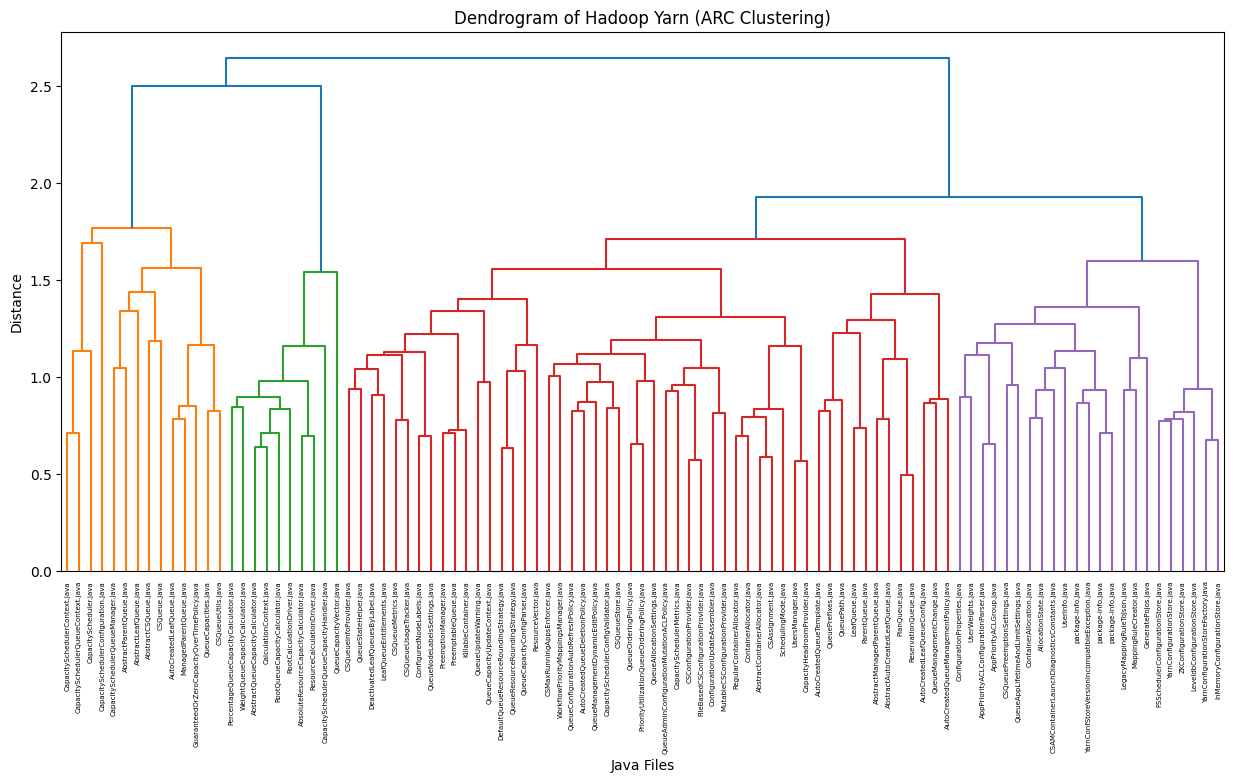

In [97]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Since AgglomerativeClustering doesn't easily provide the 'linkage matrix'
# needed for a dendrogram, we use scipy to recreate it from your distance_matrix.
linked = linkage(distance_matrix, method='complete')

plt.figure(figsize=(15, 7))
dendrogram(linked,
           orientation='top',
           labels=[path.name for path in SOURCE_CODE_DIR.rglob('*.java')],
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram of Hadoop Yarn (ARC Clustering)')
plt.xlabel('Java Files')
plt.ylabel('Distance')
plt.xticks(rotation=90)
plt.show()

2. Distance Matrix Heatmap

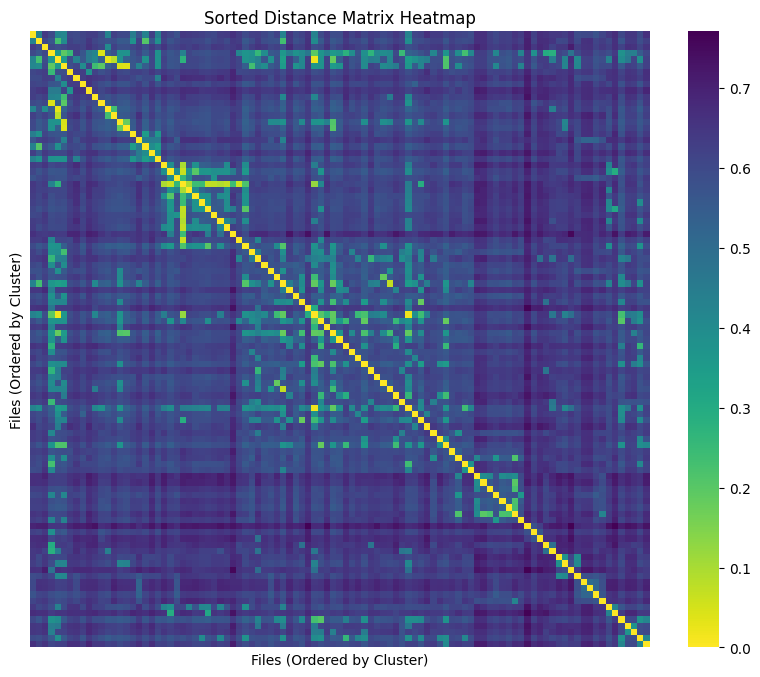

In [98]:
import seaborn as sns

# Sort indices by cluster label to make blocks visible
sorted_indices = np.argsort(clusters)
sorted_matrix = distance_matrix[sorted_indices][:, sorted_indices]

plt.figure(figsize=(10, 8))
sns.heatmap(sorted_matrix, cmap='viridis_r', xticklabels=False, yticklabels=False)
plt.title('Sorted Distance Matrix Heatmap')
plt.xlabel('Files (Ordered by Cluster)')
plt.ylabel('Files (Ordered by Cluster)')
plt.show()

3. 2D Cluster Scatter Plot (using PCA)

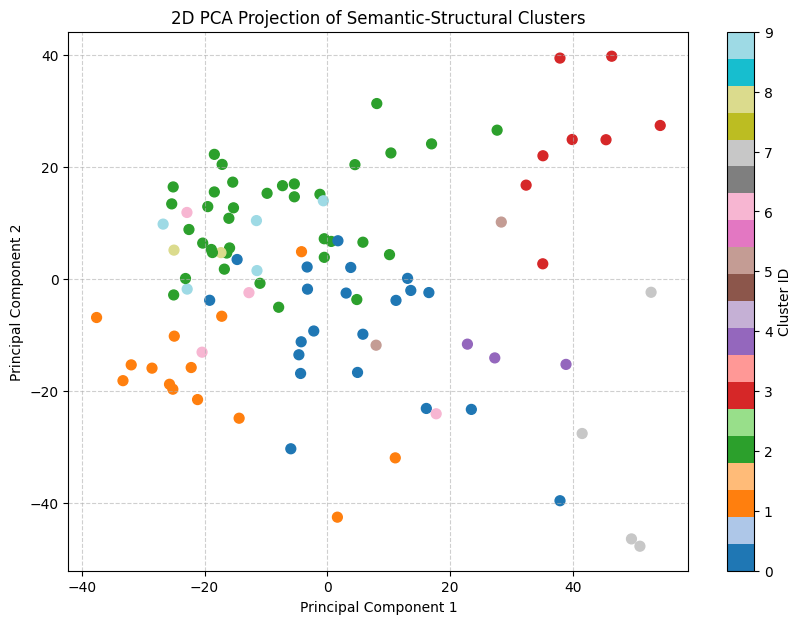

In [99]:
from sklearn.decomposition import PCA

# Project the embeddings into 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=clusters, cmap='tab20', s=50)
plt.colorbar(scatter, label='Cluster ID')
plt.title('2D PCA Projection of Semantic-Structural Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Exporting our Week 3 Clusters to an .rsf File

In [100]:
# Path where your Week 3 ARC clusters will be saved
arc_output_rsf = "/content/group10_week3_arc_clusters.rsf"

# Write the clusters out in RSF format: contain Class_Name Cluster_ID
with open(arc_output_rsf, "w") as f:
    for path, cluster_id in zip(file_paths, clusters):
        # Format: contain Cluster_ID Class_Name
        f.write(f"contain cluster_{cluster_id} {path.stem}\n")

print(f"Successfully exported Week 3 ARC clusters to: {arc_output_rsf}")

Successfully exported Week 3 ARC clusters to: /content/group10_week3_arc_clusters.rsf
